# 90 — Exported Model Sanity Audit (leakage, threshold, domain fingerprint)

This notebook reads the artefacts produced by `scripts/audit_exported_models_leakage_domain.py` and renders them for thesis use.

**Important — what this notebook is and is NOT**

- It does **not** retrain production models.
- It does **not** prove production readiness.
- It is purely a read-only audit over the validated model registry.
- High known-domain performance is **not** equal to unseen-domain robustness — the LODO `negative_control` collapses remain the stronger warning for deployment in unseen environments.
- `robust9_firewall` remains a **known-domain default firewall prototype**, not a universal VPN detector.

In [1]:
import json, sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
while not (ROOT / 'backend' / 'model_registry').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
print('Project root:', ROOT)

TABLES = ROOT / 'reports' / 'tables'
FIGURES = ROOT / 'reports' / 'figures'

def load(name):
    p = TABLES / name
    return pd.read_csv(p) if p.exists() else None

leak  = load('exported_models_leakage_summary.csv')
pol   = load('exported_models_policy_sanity.csv')
recon = load('exported_models_session_reconstruction.csv')
perds = load('exported_models_per_dataset_confusion.csv')
perm  = load('exported_models_label_permutation.csv')
boot  = load('exported_models_bootstrap_ci.csv')
dist  = load('exported_models_score_distribution_summary.csv')
dom   = load('exported_models_domain_fingerprint_audit.csv')

registry = json.loads((ROOT / 'backend' / 'model_registry' / 'registry.json').read_text(encoding='utf-8'))
print('Registry entries:', len(registry['models']))

Project root: C:\Users\scoti\PycharmProjects\ai-vpn-firewall
Registry entries: 14


## 1. Purpose and scope

We audit every entry currently in `backend/model_registry/registry.json` for:

1. Direct split leakage (`flow_id` / `capture_id` overlap; suspicious feature names).
2. Policy safety (strict/balanced actions vs measured test FPR).
3. Session reconstruction (rebuild test session scores at the packaged threshold).
4. Label-permutation sanity (does AUC collapse to 0.5 under label shuffles?).
5. Bootstrap 95% CI on session AUC / strict recall / strict FPR.
6. Score distribution per split / dataset / label.
7. Domain fingerprinting (does the feature set predict the source dataset?).

All numbers come from `predictions.csv` / `*_predictions.parquet` files referenced by the registry. Nothing is retrained.

## 2. Registry overview

In [2]:
rows = []
for mid, e in registry['models'].items():
    rows.append({
        'model_id': mid,
        'status': e.get('status'),
        'supports_firewall_actions': e.get('supports_firewall_actions'),
        'supports_live_mode': e.get('supports_live_mode'),
        'deployable': e.get('deployable'),
        'session_auc_test': e.get('session_auc_test'),
        'strict_test_fpr': e.get('strict_test_fpr'),
        'strict_test_recall': e.get('strict_test_recall'),
        'package_dir': e.get('package_dir'),
    })
pd.DataFrame(rows).set_index('model_id')

,status,supports_firewall_actions,supports_live_mode,deployable,session_auc_test,strict_test_fpr,strict_test_recall,package_dir
model_id,,,,,,,,
robust9_firewall,default_firewall,None,None,None,0.999109,0.000000,0.909091,backend/model_registry/robust9_firewall
balanced_bagging_3ds_reference,policy_computed,None,None,None,0.950495,0.000000,0.400000,backend/model_registry/balanced_bagging_3ds_re...
balanced_bagging_3ds_refresh,alias,None,None,None,NaN,NaN,NaN,backend/model_registry/balanced_bagging_3ds_re...
clean_pooled_benchmark,policy_computed,None,None,None,0.998756,0.125000,1.000000,backend/model_registry/clean_pooled_benchmark
twentyone_feature_experimental,unsupported,None,None,None,NaN,NaN,NaN,backend/model_registry/twentyone_feature_exper...
single_model_fallback,policy_computed,None,None,None,1.000000,0.041667,1.000000,backend/model_registry/single_model_fallback
lodo_hold_iscx,negative_control,False,False,False,0.562297,0.000000,0.000000,backend/model_registry/lodo_hold_iscx
lodo_hold_usbvpn,negative_control,False,False,False,0.813432,0.000000,0.043478,backend/model_registry/lodo_hold_usbvpn
lodo_hold_vnat,negative_control,False,False,False,0.175904,0.000000,0.000000,backend/model_registry/lodo_hold_vnat


## 3. Direct leakage audit

**Rule**: a model can only be marked `default_firewall` or `policy_packaged` if every train/val/test overlap count is zero AND no `feature_order.json` column is in the leaky meta-name list.

Looking for nonzero `flow_overlap_*` / `capture_overlap_*` and non-empty `suspicious_feature_columns`.

In [3]:
display(leak)
n_overlap = int((leak['leakage_status'] == 'overlap_detected').sum())
n_susp = int(leak['suspicious_feature_columns'].fillna('').astype(str).str.len().gt(0).sum())
display(Markdown(
    f'**Overlap-detected models**: {n_overlap}.  '
    f'**Models with suspicious feature columns**: {n_susp}.'
))

,model_id,status,leakage_status,reason,flow_overlap_train_val,flow_overlap_train_test,flow_overlap_val_test,capture_overlap_train_val,capture_overlap_train_test,capture_overlap_val_test,feature_order_n,suspicious_feature_columns
0,robust9_firewall,default_firewall,no_direct_overlap_detected,NaN,0.0,0.0,0.0,0.0,0.0,0.0,9.0,NaN
1,balanced_bagging_3ds_reference,policy_computed,no_direct_overlap_detected,NaN,0.0,0.0,0.0,0.0,0.0,0.0,7.0,NaN
2,balanced_bagging_3ds_refresh,alias,not_available,alias entry; leakage check inherited from target,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,clean_pooled_benchmark,policy_computed,no_direct_overlap_detected,NaN,0.0,0.0,0.0,0.0,0.0,0.0,9.0,NaN
4,twentyone_feature_experimental,unsupported,not_available,unsupported stub; no predictions or feature or...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,single_model_fallback,policy_computed,no_direct_overlap_detected,NaN,0.0,0.0,0.0,0.0,0.0,0.0,9.0,NaN
6,lodo_hold_iscx,negative_control,no_direct_overlap_detected,NaN,0.0,0.0,0.0,0.0,0.0,0.0,7.0,NaN
7,lodo_hold_usbvpn,negative_control,no_direct_overlap_detected,NaN,0.0,0.0,0.0,0.0,0.0,0.0,7.0,NaN
8,lodo_hold_vnat,negative_control,no_direct_overlap_detected,NaN,0.0,0.0,0.0,0.0,0.0,0.0,7.0,NaN
9,balanced_bagging_xgb_baseline,policy_computed,no_direct_overlap_detected,NaN,0.0,0.0,0.0,0.0,0.0,0.0,27.0,NaN


**Overlap-detected models**: 0.  **Models with suspicious feature columns**: 0.

## 4. Policy safety audit

Rules enforced:

- `strict.action == "BLOCK"` only when `strict_test_fpr == 0`.
- `balanced.action != "BLOCK"`.
- `negative_control` ⇒ `supports_firewall_actions == false`.
- `policy_computed` ⇒ warning contains `"comparison-only"`.

In [4]:
display(pol)
n_fail = int((pol['policy_sanity_status'] == 'fail').sum())
display(Markdown(f'**Policy sanity failures**: {n_fail}.'))

,model_id,status,policy_sanity_status,issues,strict_action,balanced_action,strict_test_fpr,balanced_test_fpr,supports_firewall_actions,warnings_present
0,robust9_firewall,default_firewall,pass,NaN,BLOCK,FLAG_REVIEW,0.000000,0.000000,NaN,[]
1,balanced_bagging_3ds_reference,policy_computed,pass,NaN,BLOCK,FLAG_REVIEW,0.000000,0.000000,NaN,"[""comparison-only, not deployment-approved""]"
2,balanced_bagging_3ds_refresh,alias,not_available,alias entry; policy inherited,NaN,NaN,NaN,NaN,NaN,[]
3,clean_pooled_benchmark,policy_computed,pass,NaN,DISABLED_DO_NOT_BLOCK,FLAG_REVIEW,0.125000,0.000000,NaN,"[""comparison-only, not deployment-approved""]"
4,twentyone_feature_experimental,unsupported,pass,unsupported stub; no policy expected,NaN,NaN,NaN,NaN,NaN,"[""No recoverable 21-feature artifact exists in..."
5,single_model_fallback,policy_computed,pass,NaN,DISABLED_DO_NOT_BLOCK,FLAG_REVIEW,0.041667,0.000000,NaN,"[""comparison-only, not deployment-approved""]"
6,lodo_hold_iscx,negative_control,pass,NaN,NaN,NaN,0.000000,0.000000,False,"[""Negative control / LODO stress-test model. N..."
7,lodo_hold_usbvpn,negative_control,pass,NaN,NaN,NaN,0.000000,0.000000,False,"[""Negative control / LODO stress-test model. N..."
8,lodo_hold_vnat,negative_control,pass,NaN,NaN,NaN,0.000000,0.000000,False,"[""Negative control / LODO stress-test model. N..."
9,balanced_bagging_xgb_baseline,policy_computed,pass,NaN,BLOCK,FLAG_REVIEW,0.000000,0.000000,True,"[""comparison-only, not deployment-approved""]"


**Policy sanity failures**: 0.

,model_id,status,policy_sanity_status,issues,strict_action,balanced_action,strict_test_fpr,balanced_test_fpr,supports_firewall_actions,warnings_present
0,robust9_firewall,default_firewall,pass,NaN,BLOCK,FLAG_REVIEW,0.000000,0.000000,NaN,[]
1,balanced_bagging_3ds_reference,policy_computed,pass,NaN,BLOCK,FLAG_REVIEW,0.000000,0.000000,NaN,"[""comparison-only, not deployment-approved""]"
2,balanced_bagging_3ds_refresh,alias,not_available,alias entry; policy inherited,NaN,NaN,NaN,NaN,NaN,[]
3,clean_pooled_benchmark,policy_computed,pass,NaN,DISABLED_DO_NOT_BLOCK,FLAG_REVIEW,0.125000,0.000000,NaN,"[""comparison-only, not deployment-approved""]"
4,twentyone_feature_experimental,unsupported,pass,unsupported stub; no policy expected,NaN,NaN,NaN,NaN,NaN,"[""No recoverable 21-feature artifact exists in..."
5,single_model_fallback,policy_computed,pass,NaN,DISABLED_DO_NOT_BLOCK,FLAG_REVIEW,0.041667,0.000000,NaN,"[""comparison-only, not deployment-approved""]"
6,lodo_hold_iscx,negative_control,pass,NaN,NaN,NaN,0.000000,0.000000,False,"[""Negative control / LODO stress-test model. N..."
7,lodo_hold_usbvpn,negative_control,pass,NaN,NaN,NaN,0.000000,0.000000,False,"[""Negative control / LODO stress-test model. N..."
8,lodo_hold_vnat,negative_control,pass,NaN,NaN,NaN,0.000000,0.000000,False,"[""Negative control / LODO stress-test model. N..."
9,balanced_bagging_xgb_baseline,policy_computed,pass,NaN,BLOCK,FLAG_REVIEW,0.000000,0.000000,True,"[""comparison-only, not deployment-approved""]"


**Policy sanity failures**: 0.

## 5. Session metric reconstruction

For each non-alias, non-unsupported model we rebuild val / test session tables using the packaged probability column + aggregation + threshold, and recompute strict / balanced recall and FPR plus session AUC.

In [5]:
show_cols = ['model_id','status','selected_probability_column','selected_aggregation',
             'n_val_sessions','n_test_sessions',
             'strict_recall_test','strict_fpr_test',
             'balanced_recall_test','balanced_fpr_test',
             'session_auc_test','reason']
recon[show_cols]

,model_id,status,selected_probability_column,selected_aggregation,n_val_sessions,n_test_sessions,strict_recall_test,strict_fpr_test,balanced_recall_test,balanced_fpr_test,session_auc_test,reason
0,robust9_firewall,default_firewall,prob_iso,p80,120.0,124.0,0.909091,0.000000,0.909091,0.000000,0.999109,NaN
1,balanced_bagging_3ds_reference,policy_computed,prob_raw,wt5,102.0,106.0,0.400000,0.000000,0.400000,0.000000,0.950495,NaN
2,balanced_bagging_3ds_refresh,alias,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,alias entry
3,clean_pooled_benchmark,policy_computed,ensemble_score,p80,16.0,91.0,1.000000,0.125000,0.731343,0.000000,0.998756,NaN
4,twentyone_feature_experimental,unsupported,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unsupported entry
5,single_model_fallback,policy_computed,xgb_score,p80,16.0,91.0,1.000000,0.041667,0.776119,0.000000,1.000000,NaN
6,lodo_hold_iscx,negative_control,prob_iso,p80,85.0,140.0,0.000000,0.000000,0.000000,0.000000,0.562297,NaN
7,lodo_hold_usbvpn,negative_control,prob_platt,wt5,29.0,504.0,0.043478,0.000000,0.043478,0.000000,0.813432,NaN
8,lodo_hold_vnat,negative_control,prob_platt,p80,90.0,88.0,0.000000,0.000000,0.000000,0.000000,0.175904,NaN
9,balanced_bagging_xgb_baseline,policy_computed,prob_raw,wt5,120.0,124.0,0.090909,0.000000,0.681818,0.000000,0.971034,NaN


,model_id,status,selected_probability_column,selected_aggregation,n_val_sessions,n_test_sessions,strict_recall_test,strict_fpr_test,balanced_recall_test,balanced_fpr_test,session_auc_test,reason
0,robust9_firewall,default_firewall,prob_iso,p80,120.0,124.0,0.909091,0.000000,0.909091,0.000000,0.999109,NaN
1,balanced_bagging_3ds_reference,policy_computed,prob_raw,wt5,102.0,106.0,0.400000,0.000000,0.400000,0.000000,0.950495,NaN
2,balanced_bagging_3ds_refresh,alias,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,alias entry
3,clean_pooled_benchmark,policy_computed,ensemble_score,p80,16.0,91.0,1.000000,0.125000,0.731343,0.000000,0.998756,NaN
4,twentyone_feature_experimental,unsupported,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unsupported entry
5,single_model_fallback,policy_computed,xgb_score,p80,16.0,91.0,1.000000,0.041667,0.776119,0.000000,1.000000,NaN
6,lodo_hold_iscx,negative_control,prob_iso,p80,85.0,140.0,0.000000,0.000000,0.000000,0.000000,0.562297,NaN
7,lodo_hold_usbvpn,negative_control,prob_platt,wt5,29.0,504.0,0.043478,0.000000,0.043478,0.000000,0.813432,NaN
8,lodo_hold_vnat,negative_control,prob_platt,p80,90.0,88.0,0.000000,0.000000,0.000000,0.000000,0.175904,NaN
9,balanced_bagging_xgb_baseline,policy_computed,prob_raw,wt5,120.0,124.0,0.090909,0.000000,0.681818,0.000000,0.971034,NaN


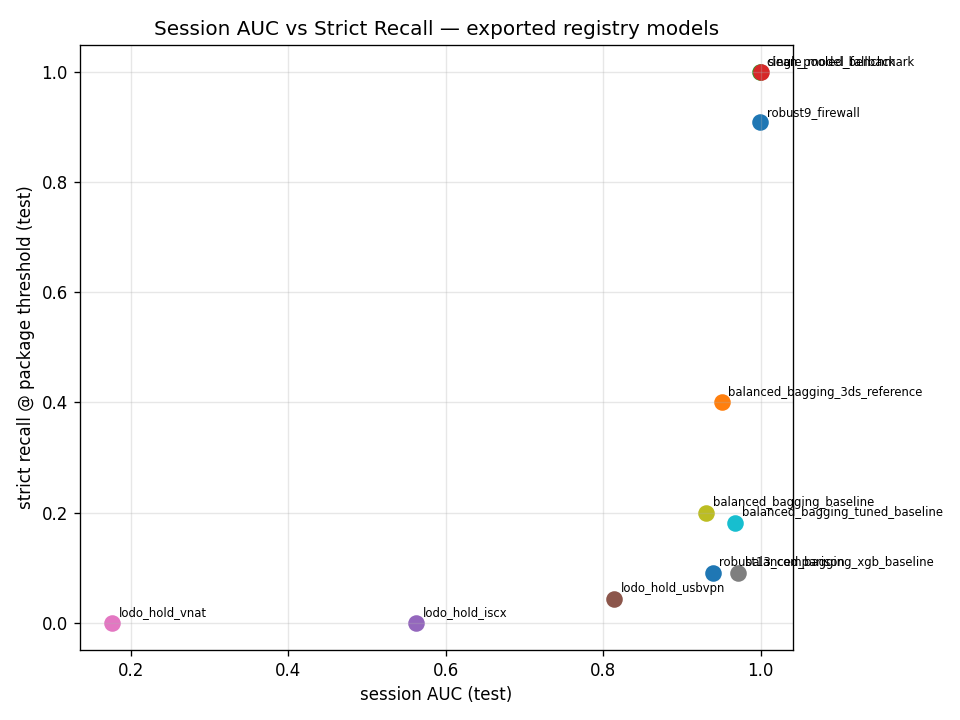

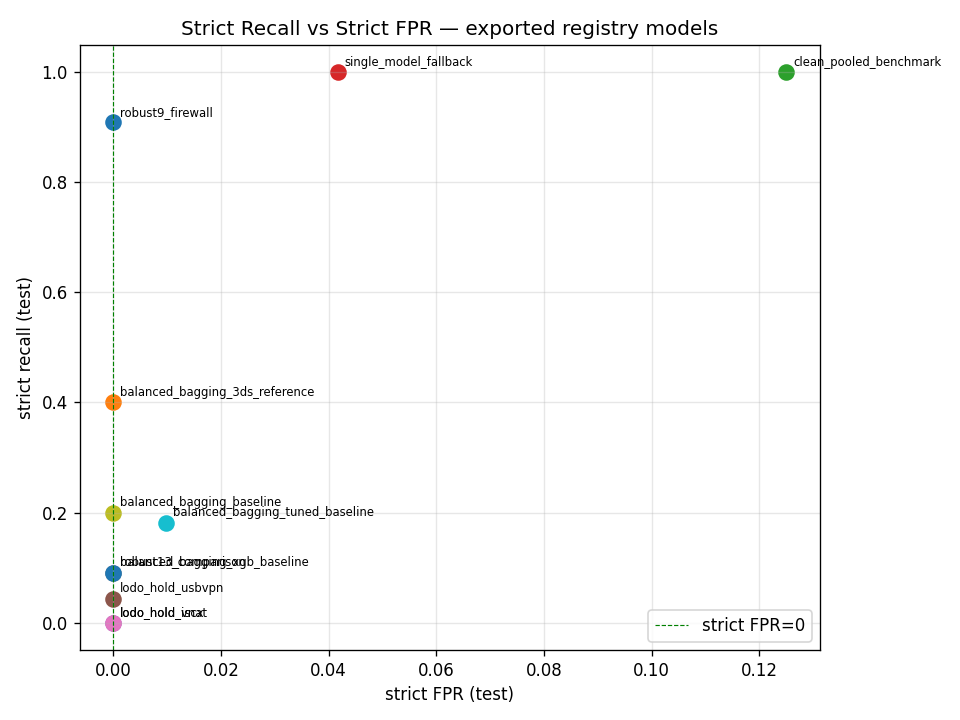

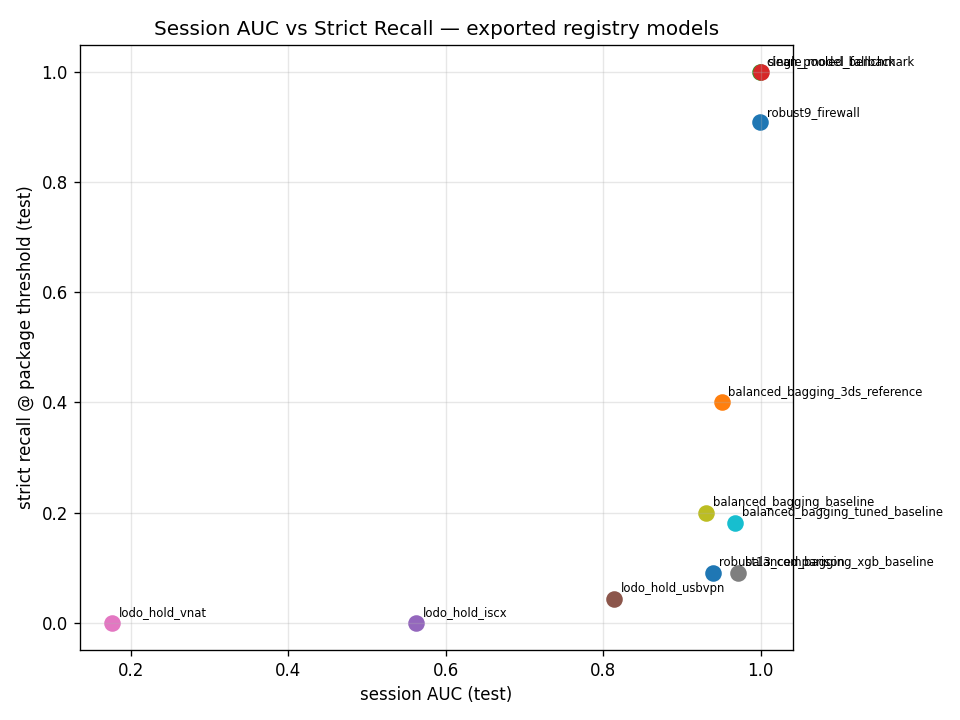

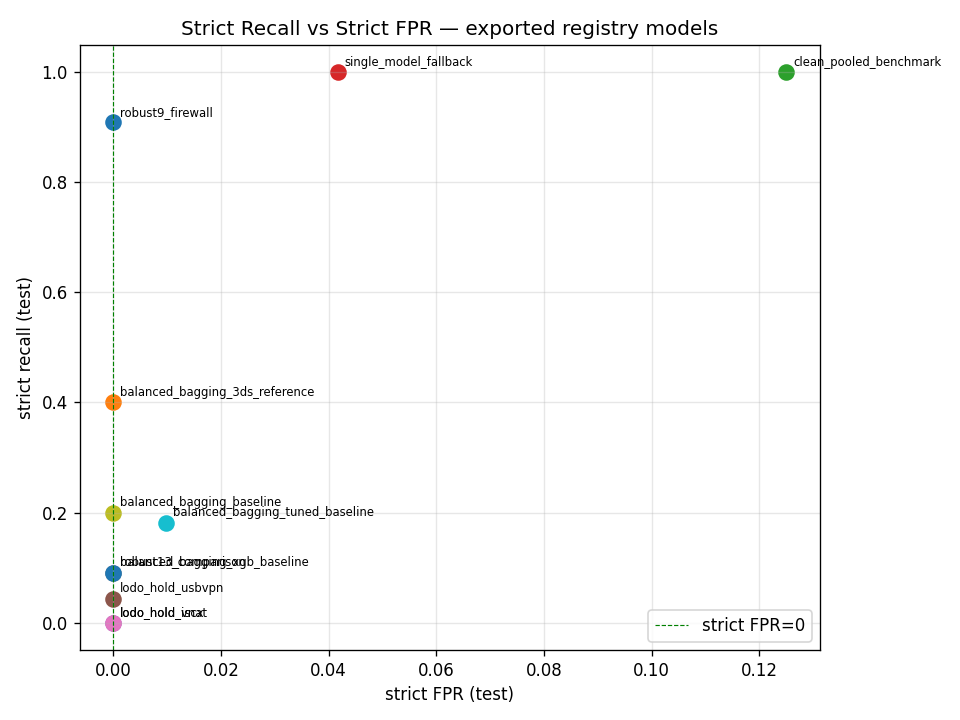

In [6]:
p = FIGURES / 'exported_models_session_auc_vs_strict_recall.png'
if p.exists():
    display(Image(filename=str(p)))
p = FIGURES / 'exported_models_strict_recall_fpr_scatter.png'
if p.exists():
    display(Image(filename=str(p)))

In [7]:
perds[['model_id','dataset','n_sessions','n_vpn','n_benign',
       'session_auc','strict_recall','strict_fpr']]

,model_id,dataset,n_sessions,n_vpn,n_benign,session_auc,strict_recall,strict_fpr
0,robust9_firewall,iscx,21,4,17,1.000000,0.750000,0.000000
1,robust9_firewall,usbvpn,77,5,72,1.000000,1.000000,0.000000
2,robust9_firewall,vnat,26,13,13,1.000000,0.923077,0.000000
3,balanced_bagging_3ds_reference,iscx,19,2,17,0.882353,0.000000,0.000000
4,balanced_bagging_3ds_reference,usbvpn,74,2,72,1.000000,1.000000,0.000000
5,balanced_bagging_3ds_reference,vnat,13,1,12,0.833333,0.000000,0.000000
6,clean_pooled_benchmark,iscx,10,4,6,1.000000,1.000000,0.166667
7,clean_pooled_benchmark,usbvpn,8,8,0,NaN,1.000000,0.000000
8,clean_pooled_benchmark,vnat,73,55,18,1.000000,1.000000,0.111111
9,single_model_fallback,iscx,10,4,6,1.000000,1.000000,0.000000


,model_id,dataset,n_sessions,n_vpn,n_benign,session_auc,strict_recall,strict_fpr
0,robust9_firewall,iscx,21,4,17,1.000000,0.750000,0.000000
1,robust9_firewall,usbvpn,77,5,72,1.000000,1.000000,0.000000
2,robust9_firewall,vnat,26,13,13,1.000000,0.923077,0.000000
3,balanced_bagging_3ds_reference,iscx,19,2,17,0.882353,0.000000,0.000000
4,balanced_bagging_3ds_reference,usbvpn,74,2,72,1.000000,1.000000,0.000000
5,balanced_bagging_3ds_reference,vnat,13,1,12,0.833333,0.000000,0.000000
6,clean_pooled_benchmark,iscx,10,4,6,1.000000,1.000000,0.166667
7,clean_pooled_benchmark,usbvpn,8,8,0,NaN,1.000000,0.000000
8,clean_pooled_benchmark,vnat,73,55,18,1.000000,1.000000,0.111111
9,single_model_fallback,iscx,10,4,6,1.000000,1.000000,0.000000


## 6. Label permutation sanity check

We shuffle test session labels 200 times and recompute AUC. The expected median is **≈ 0.5**. A median consistently far from 0.5 would suggest that score and label are coupled through metadata rather than features.

In [8]:
perm[['model_id','n_perm','auc_mean','auc_std','auc_p05','auc_p50','auc_p95','reason']]

,model_id,n_perm,auc_mean,auc_std,auc_p05,auc_p50,auc_p95,reason
0,robust9_firewall,200,0.498035,0.073564,0.381194,0.500668,0.621212,NaN
1,balanced_bagging_3ds_reference,200,0.506168,0.122503,0.304752,0.498020,0.713069,NaN
2,balanced_bagging_3ds_refresh,0,NaN,NaN,NaN,NaN,NaN,alias entry
3,clean_pooled_benchmark,200,0.497472,0.068501,0.388619,0.490983,0.614428,NaN
4,twentyone_feature_experimental,0,NaN,NaN,NaN,NaN,NaN,unsupported entry
5,single_model_fallback,200,0.500386,0.067765,0.387671,0.501399,0.608256,NaN
6,lodo_hold_iscx,200,0.503236,0.040152,0.430416,0.501258,0.561557,NaN
7,lodo_hold_usbvpn,200,0.501026,0.065228,0.391562,0.503277,0.604113,NaN
8,lodo_hold_vnat,200,0.493771,0.138797,0.272169,0.486747,0.733253,NaN
9,balanced_bagging_xgb_baseline,200,0.494991,0.074740,0.382409,0.499332,0.622014,NaN


,model_id,n_perm,auc_mean,auc_std,auc_p05,auc_p50,auc_p95,reason
0,robust9_firewall,200,0.498035,0.073564,0.381194,0.500668,0.621212,NaN
1,balanced_bagging_3ds_reference,200,0.506168,0.122503,0.304752,0.498020,0.713069,NaN
2,balanced_bagging_3ds_refresh,0,NaN,NaN,NaN,NaN,NaN,alias entry
3,clean_pooled_benchmark,200,0.497472,0.068501,0.388619,0.490983,0.614428,NaN
4,twentyone_feature_experimental,0,NaN,NaN,NaN,NaN,NaN,unsupported entry
5,single_model_fallback,200,0.500386,0.067765,0.387671,0.501399,0.608256,NaN
6,lodo_hold_iscx,200,0.503236,0.040152,0.430416,0.501258,0.561557,NaN
7,lodo_hold_usbvpn,200,0.501026,0.065228,0.391562,0.503277,0.604113,NaN
8,lodo_hold_vnat,200,0.493771,0.138797,0.272169,0.486747,0.733253,NaN
9,balanced_bagging_xgb_baseline,200,0.494991,0.074740,0.382409,0.499332,0.622014,NaN


## 7. Bootstrap uncertainty

1000 resamples of the test session pool. Tighter CIs are better evidence that the headline metrics are not artefacts of small-sample variance.

In [9]:
boot[['model_id','n_boot','n_test_sessions',
      'session_auc_lo','session_auc_hi',
      'strict_recall_lo','strict_recall_hi',
      'strict_fpr_lo','strict_fpr_hi']]

,model_id,n_boot,n_test_sessions,session_auc_lo,session_auc_hi,strict_recall_lo,strict_recall_hi,strict_fpr_lo,strict_fpr_hi
0,robust9_firewall,1000,124.0,0.995670,1.000000,0.750000,1.000000,0.0,0.000000
1,balanced_bagging_3ds_reference,997,106.0,0.859833,1.000000,0.000000,1.000000,0.0,0.000000
2,balanced_bagging_3ds_refresh,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,clean_pooled_benchmark,1000,91.0,0.994436,1.000000,1.000000,1.000000,0.0,0.275966
4,twentyone_feature_experimental,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,single_model_fallback,1000,91.0,1.000000,1.000000,1.000000,1.000000,0.0,0.142857
6,lodo_hold_iscx,1000,140.0,0.502697,0.616837,0.000000,0.000000,0.0,0.000000
7,lodo_hold_usbvpn,1000,504.0,0.702995,0.915272,0.000000,0.153947,0.0,0.000000
8,lodo_hold_vnat,996,88.0,0.038832,0.390361,0.000000,0.000000,0.0,0.000000
9,balanced_bagging_xgb_baseline,1000,124.0,0.937595,0.996158,0.000000,0.227273,0.0,0.000000


,model_id,n_boot,n_test_sessions,session_auc_lo,session_auc_hi,strict_recall_lo,strict_recall_hi,strict_fpr_lo,strict_fpr_hi
0,robust9_firewall,1000,124.0,0.995670,1.000000,0.750000,1.000000,0.0,0.000000
1,balanced_bagging_3ds_reference,997,106.0,0.859833,1.000000,0.000000,1.000000,0.0,0.000000
2,balanced_bagging_3ds_refresh,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,clean_pooled_benchmark,1000,91.0,0.994436,1.000000,1.000000,1.000000,0.0,0.275966
4,twentyone_feature_experimental,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,single_model_fallback,1000,91.0,1.000000,1.000000,1.000000,1.000000,0.0,0.142857
6,lodo_hold_iscx,1000,140.0,0.502697,0.616837,0.000000,0.000000,0.0,0.000000
7,lodo_hold_usbvpn,1000,504.0,0.702995,0.915272,0.000000,0.153947,0.0,0.000000
8,lodo_hold_vnat,996,88.0,0.038832,0.390361,0.000000,0.000000,0.0,0.000000
9,balanced_bagging_xgb_baseline,1000,124.0,0.937595,0.996158,0.000000,0.227273,0.0,0.000000


## 8. Score distributions

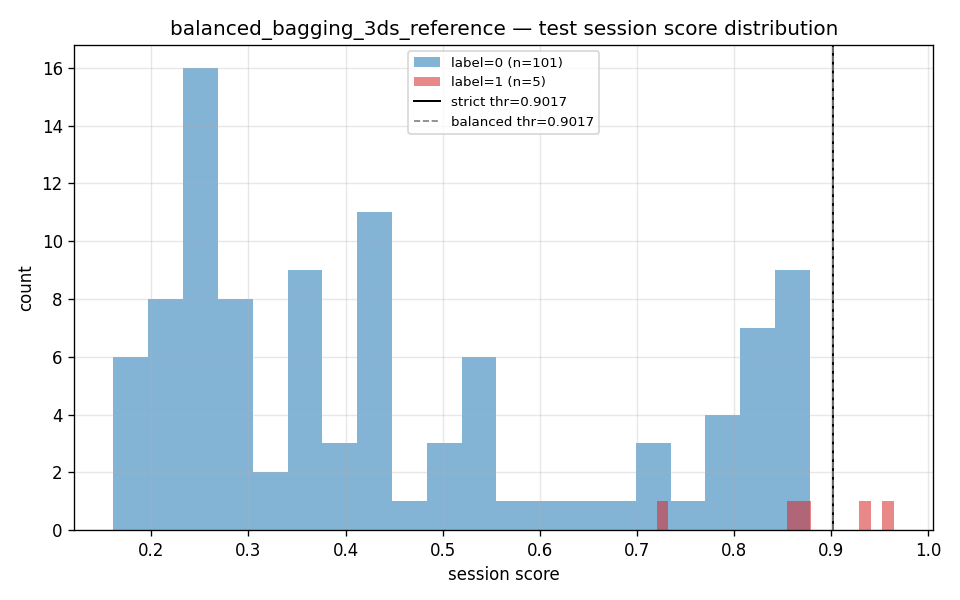

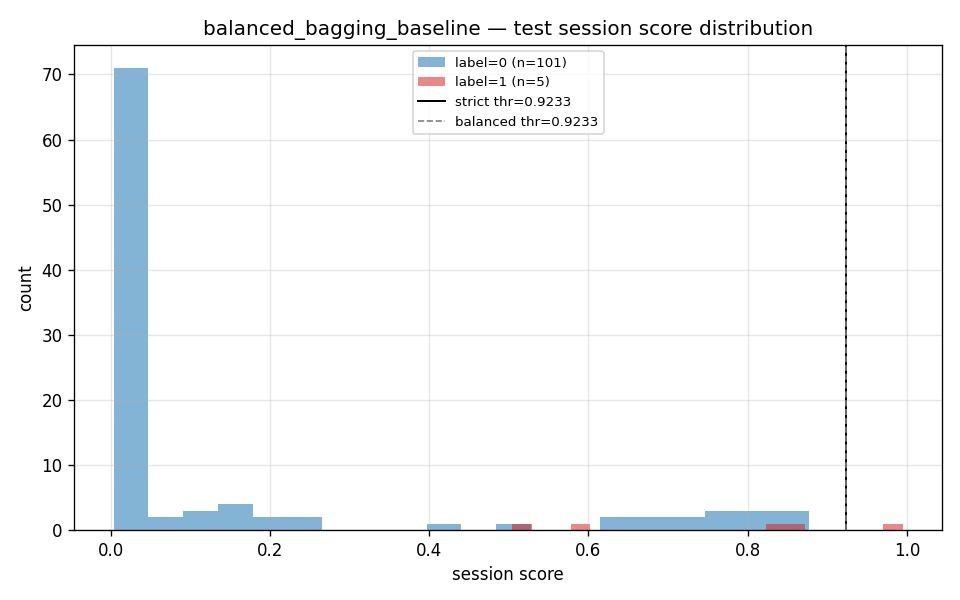

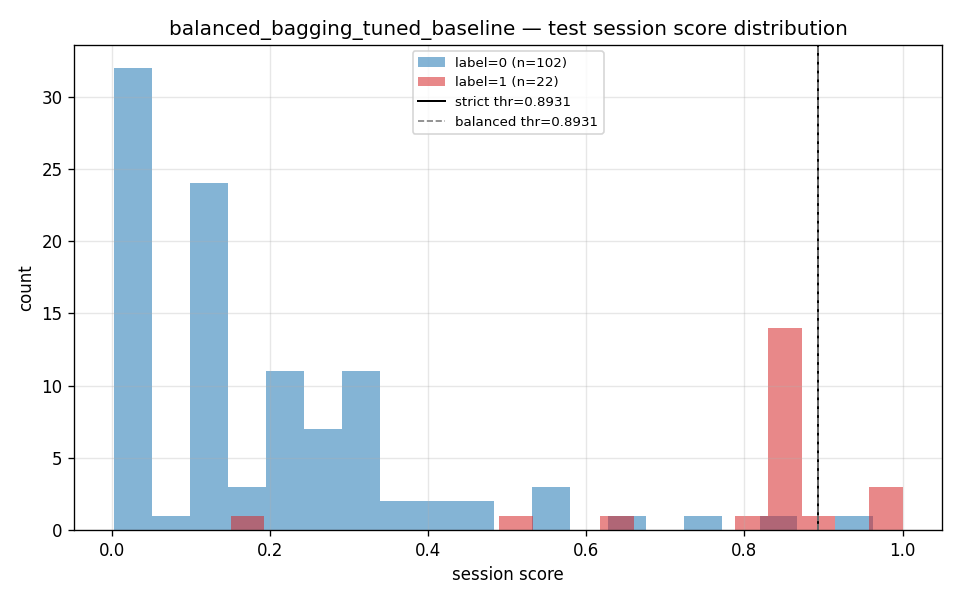

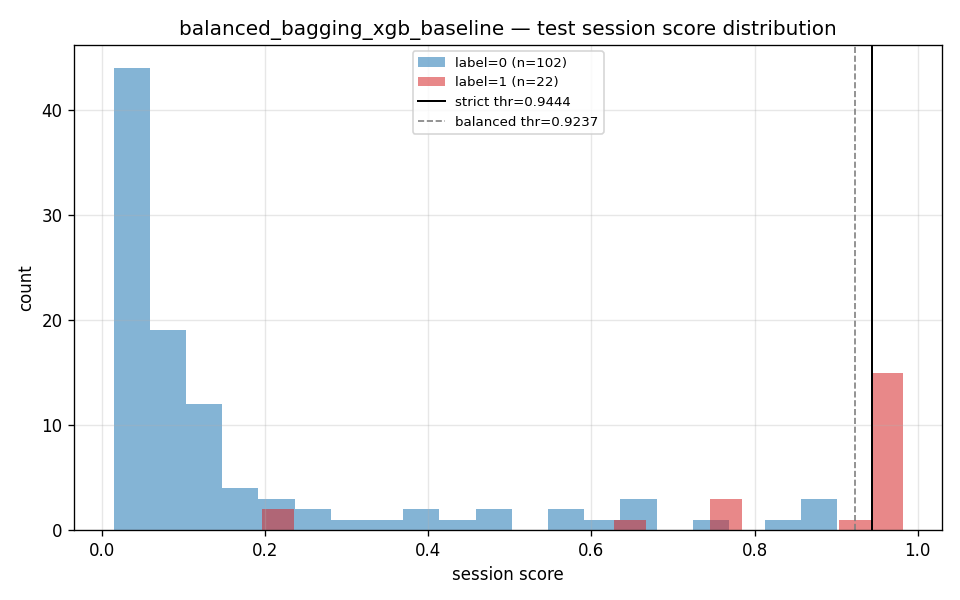

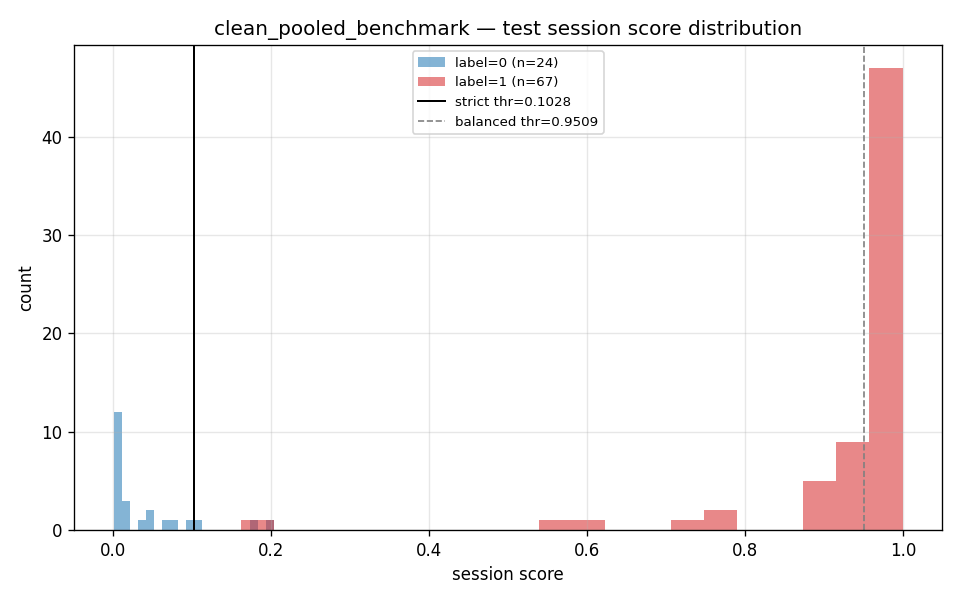

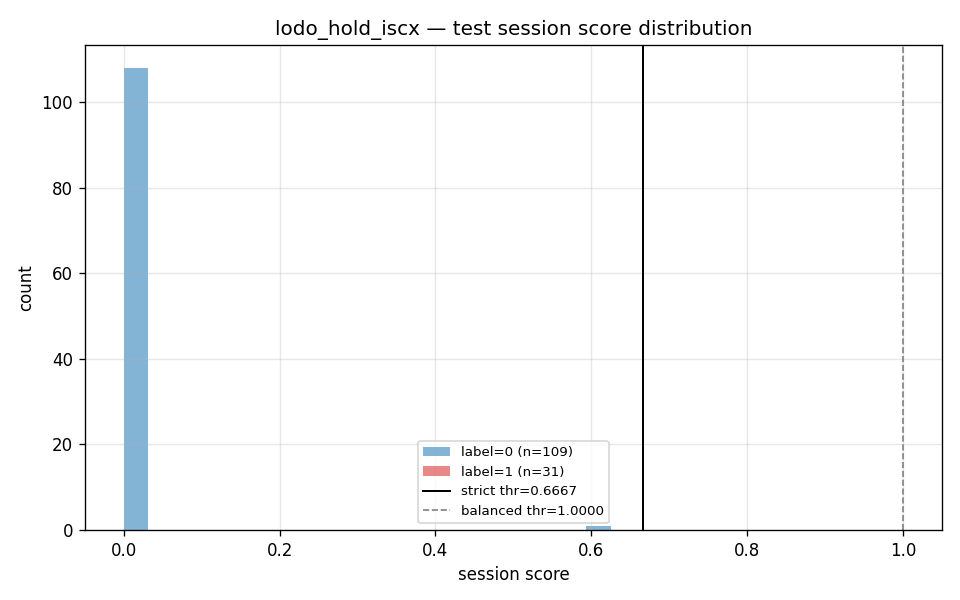

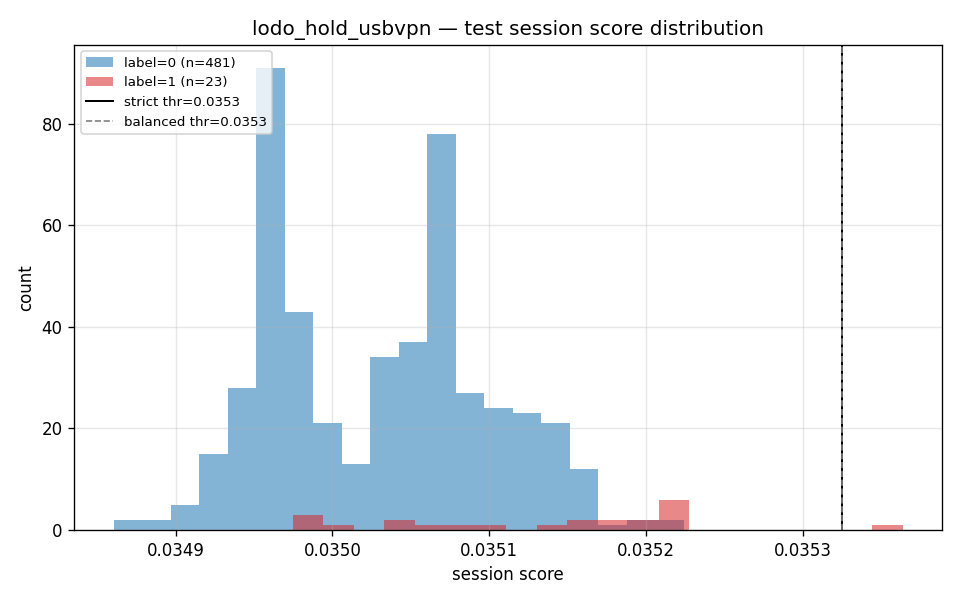

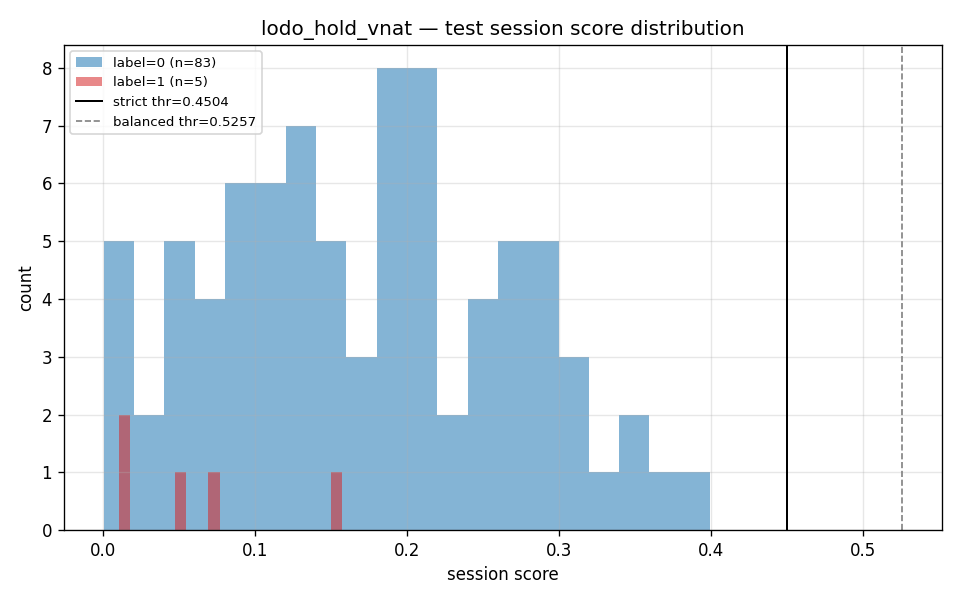

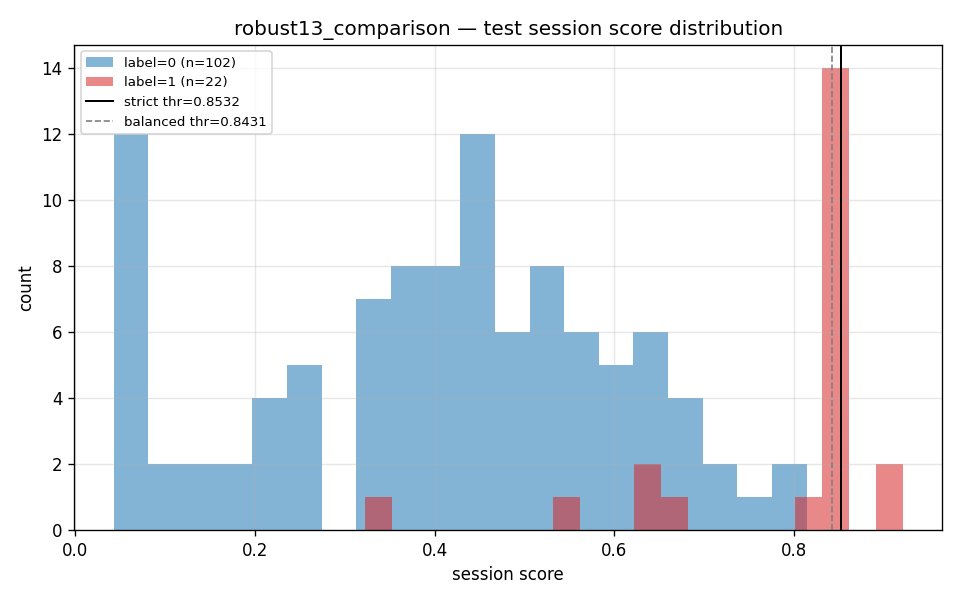

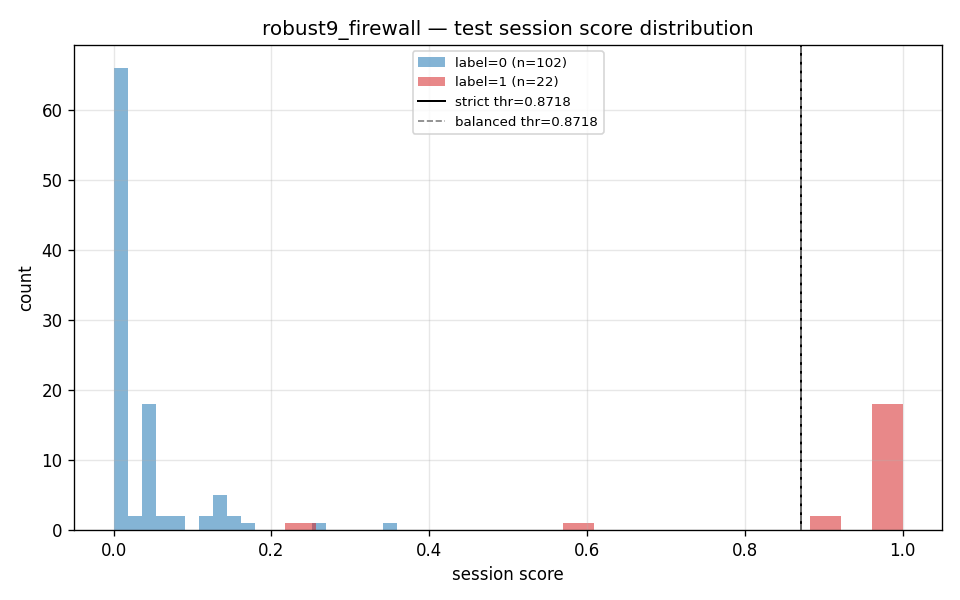

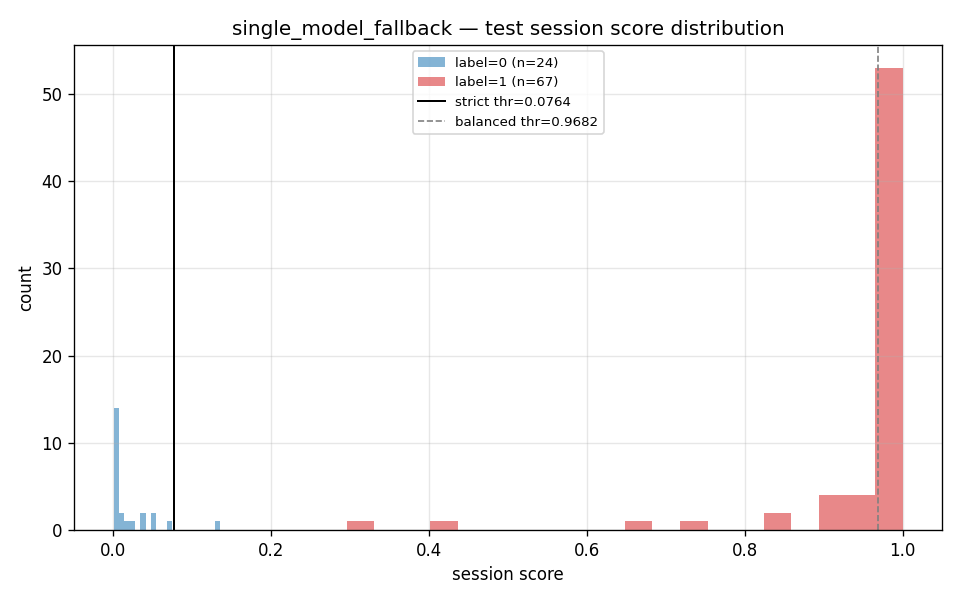

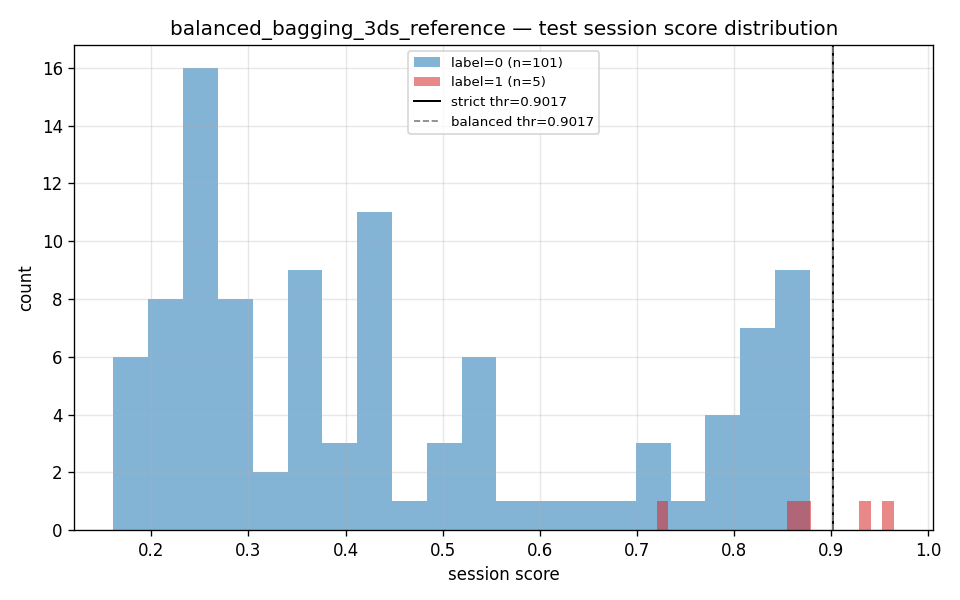

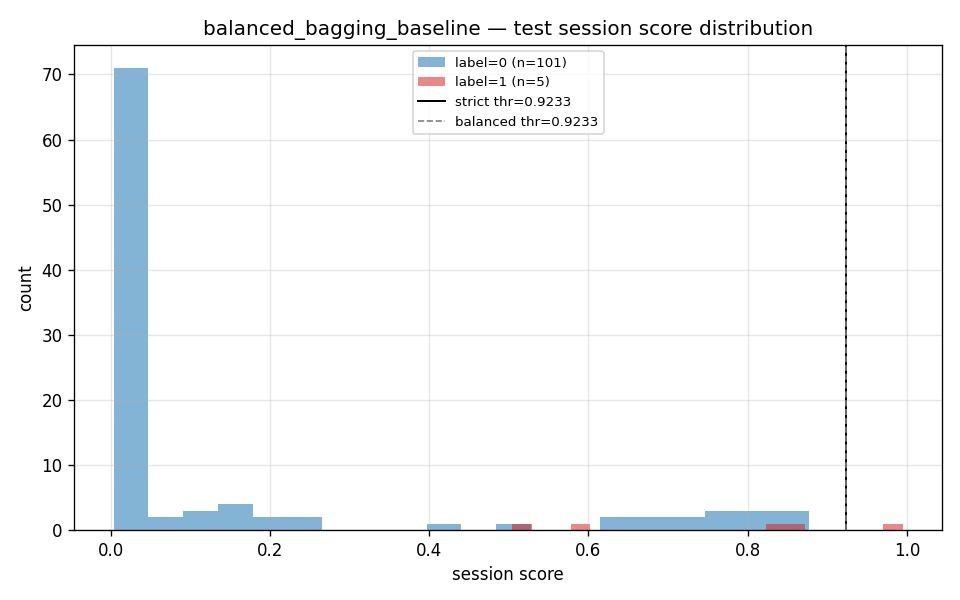

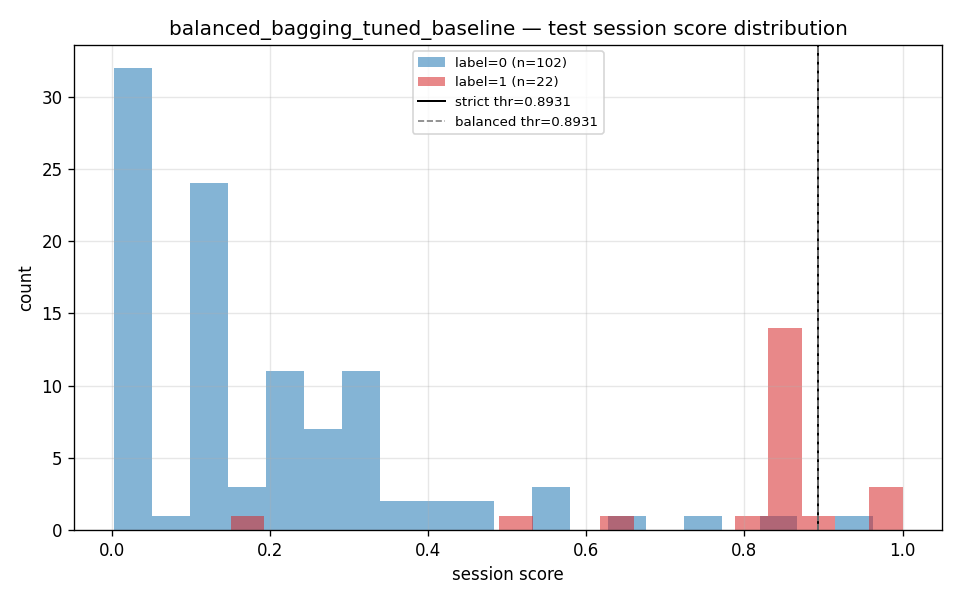

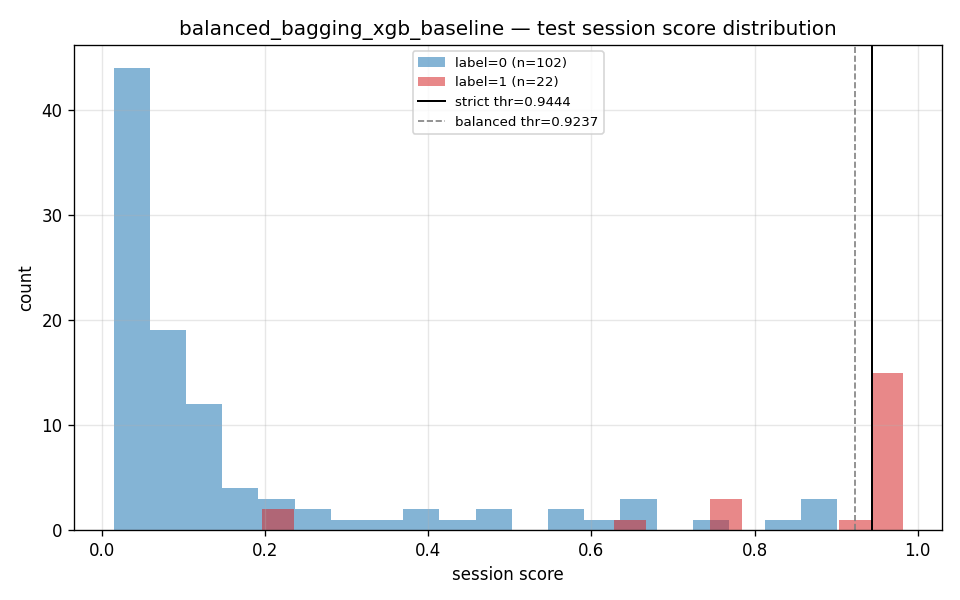

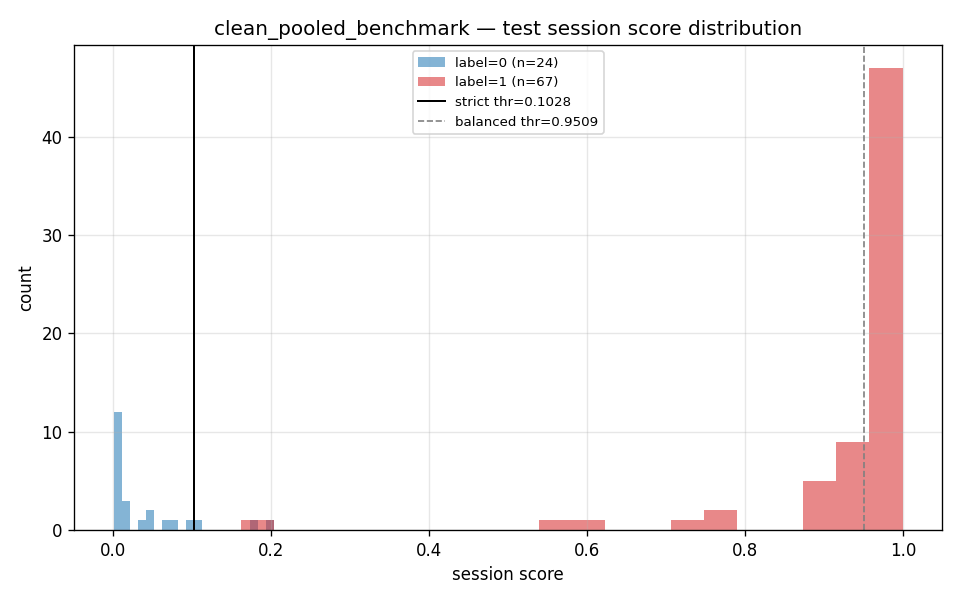

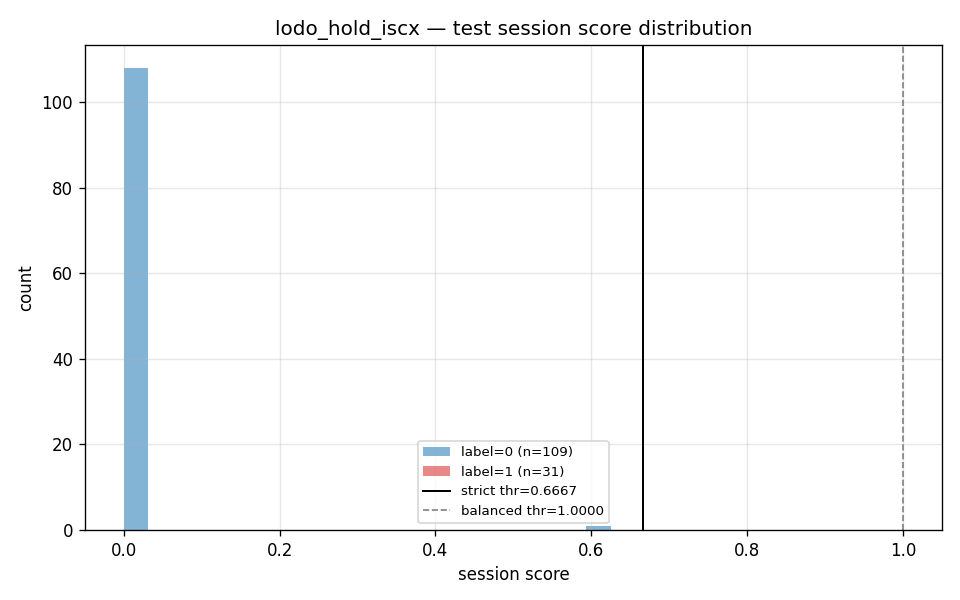

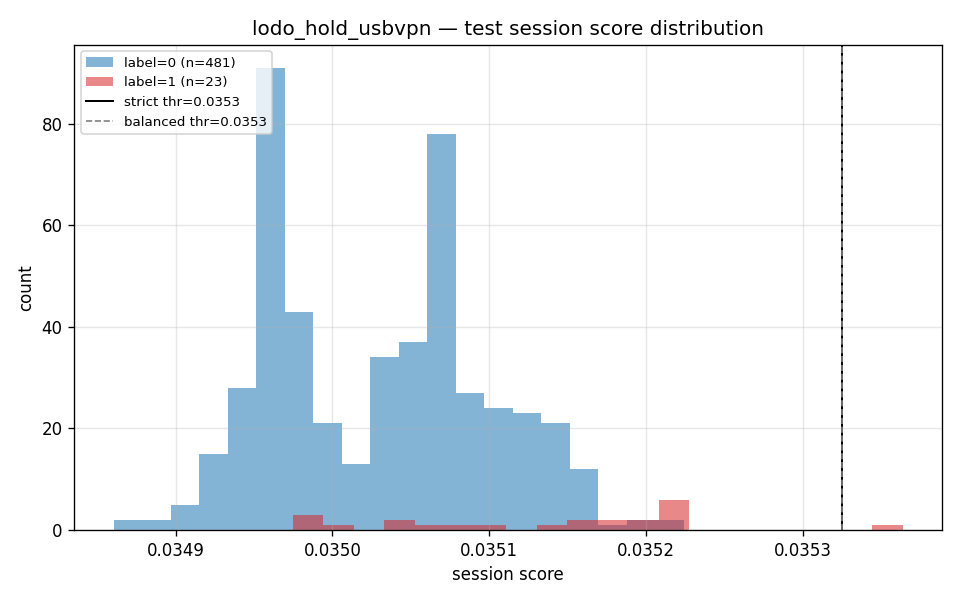

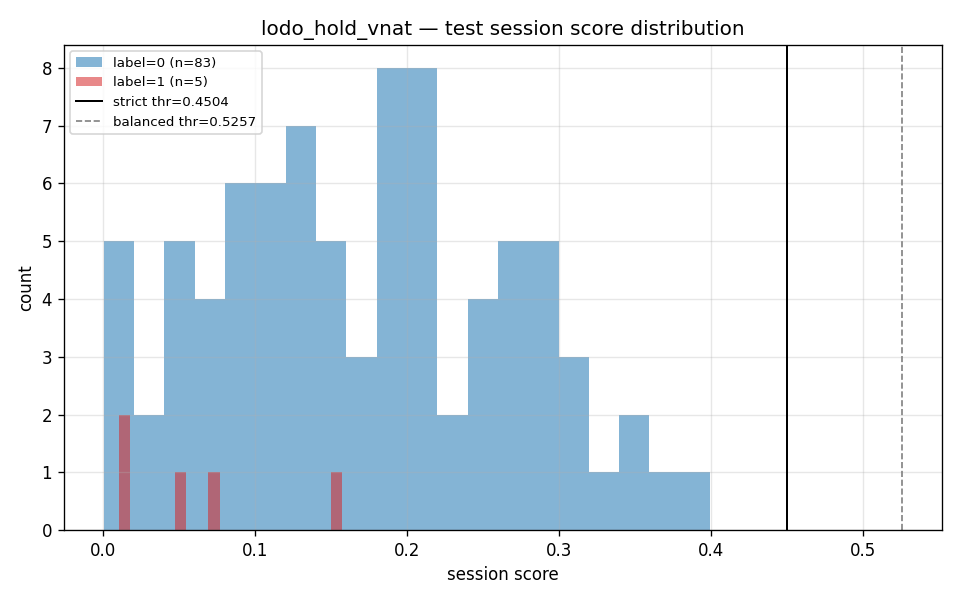

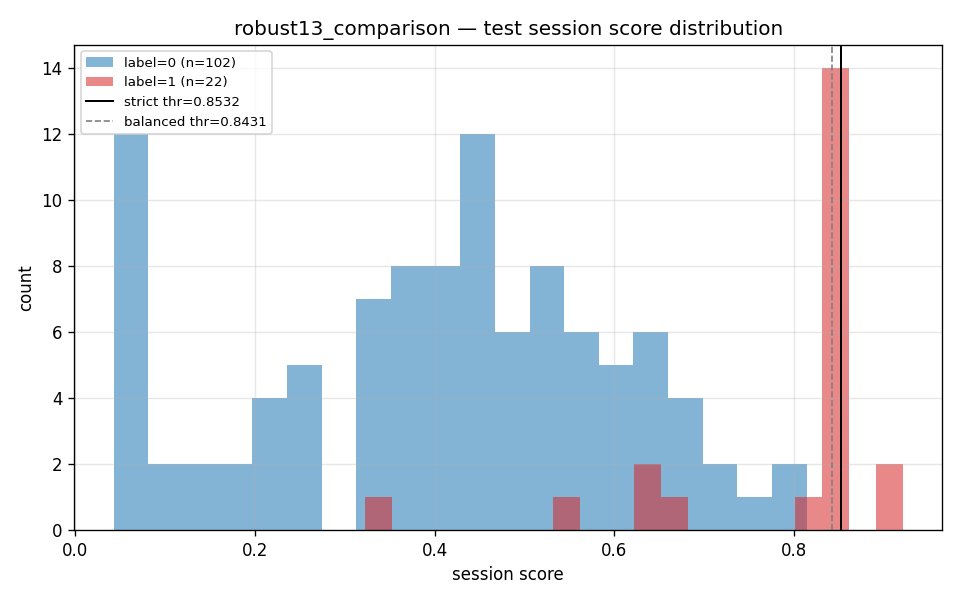

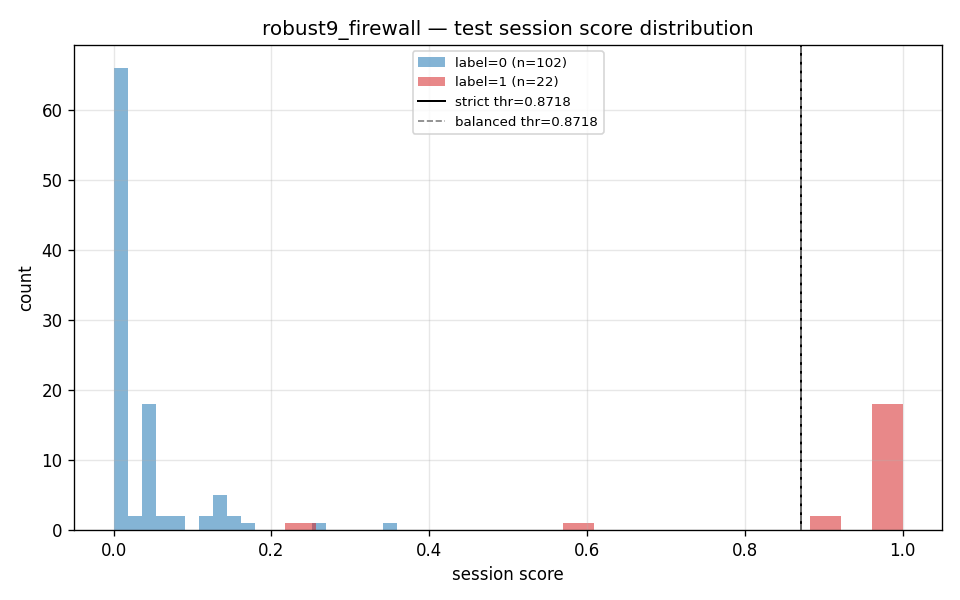

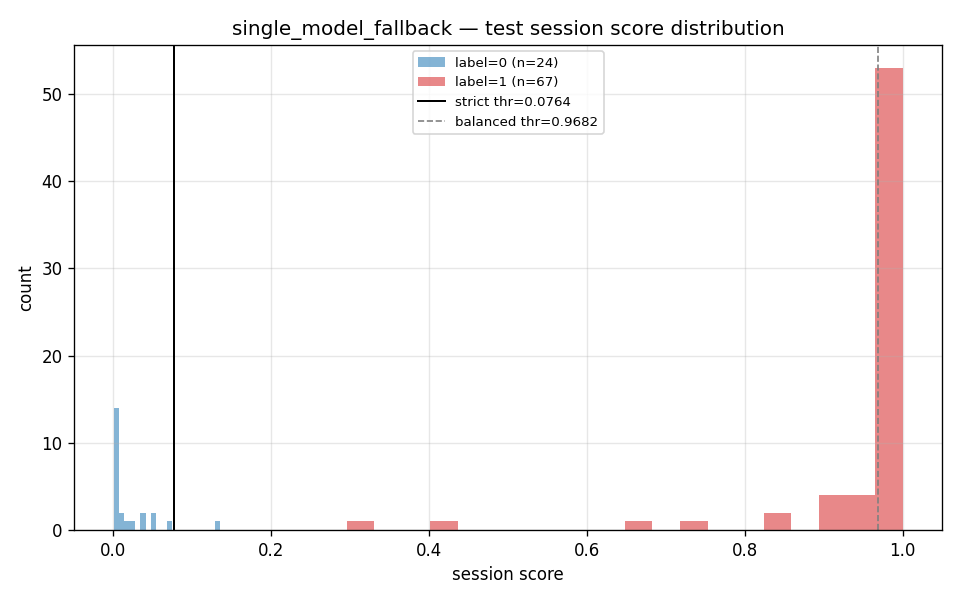

In [10]:
from IPython.display import Image, display
for f in sorted((FIGURES).glob('exported_models_score_distribution_*.png')):
    display(Image(filename=str(f)))

In [11]:
# Summary table — overall test distributions per model
dist[(dist['split']=='test') & (dist['dataset']=='_all_') & (dist['label']=='_all_')] \
    [['model_id','n','min','p25','median','p75','max','mean']]

,model_id,n,min,p25,median,p75,max,mean
10,robust9_firewall,124,0.000000,0.005777,0.011259,0.139394,1.000000,0.191539
29,balanced_bagging_3ds_reference,106,0.161020,0.264888,0.415219,0.710540,0.965162,0.476362
48,clean_pooled_benchmark,91,0.001167,0.169483,0.969115,0.979578,0.999649,0.699846
66,single_model_fallback,91,0.000411,0.103834,0.984694,0.987654,0.999842,0.704212
81,lodo_hold_iscx,140,0.000000,0.003215,0.003215,0.003215,0.624980,0.007220
91,lodo_hold_usbvpn,504,0.034860,0.034967,0.035037,0.035079,0.035364,0.035034
102,lodo_hold_vnat,88,0.000781,0.089922,0.154243,0.239624,0.399516,0.163711
116,balanced_bagging_xgb_baseline,124,0.014448,0.037247,0.101200,0.502902,0.981412,0.285683
135,balanced_bagging_baseline,106,0.004035,0.006140,0.008596,0.170264,0.994492,0.174964
155,balanced_bagging_tuned_baseline,124,0.002002,0.044217,0.197506,0.404237,1.000000,0.297012


,model_id,n,min,p25,median,p75,max,mean
10,robust9_firewall,124,0.000000,0.005777,0.011259,0.139394,1.000000,0.191539
29,balanced_bagging_3ds_reference,106,0.161020,0.264888,0.415219,0.710540,0.965162,0.476362
48,clean_pooled_benchmark,91,0.001167,0.169483,0.969115,0.979578,0.999649,0.699846
66,single_model_fallback,91,0.000411,0.103834,0.984694,0.987654,0.999842,0.704212
81,lodo_hold_iscx,140,0.000000,0.003215,0.003215,0.003215,0.624980,0.007220
91,lodo_hold_usbvpn,504,0.034860,0.034967,0.035037,0.035079,0.035364,0.035034
102,lodo_hold_vnat,88,0.000781,0.089922,0.154243,0.239624,0.399516,0.163711
116,balanced_bagging_xgb_baseline,124,0.014448,0.037247,0.101200,0.502902,0.981412,0.285683
135,balanced_bagging_baseline,106,0.004035,0.006140,0.008596,0.170264,0.994492,0.174964
155,balanced_bagging_tuned_baseline,124,0.002002,0.044217,0.197506,0.404237,1.000000,0.297012


## 9. Domain fingerprinting audit

An auxiliary RandomForest (random_state=42) is trained on each model's own feature subset (using `artifacts/clean_pipeline/features.parquet` as the unified cross-dataset feature matrix) to predict the `dataset` label. A **macro-OvR AUC well above 0.5** would be evidence that the features themselves encode dataset identity — which would help explain LODO collapses.

Note: many models in this audit have feature orders that extend beyond the unified parquet (`sz_all_*`, `iat_*`, session-prob features). Those are reported `available=False` with a precise reason and contribute *nothing* to the fingerprinting conclusion.

In [12]:
dom[['model_id','status','available','n_samples','n_features_used','n_features_required',
     'classifier','accuracy','macro_ovr_auc','reason']]

,model_id,status,available,n_samples,n_features_used,n_features_required,classifier,accuracy,macro_ovr_auc,reason
0,robust9_firewall,default_firewall,False,NaN,0.0,9.0,NaN,NaN,NaN,too few of this model's features present in un...
1,balanced_bagging_3ds_reference,policy_computed,True,4712.0,7.0,7.0,RF(existing_train_test_split),0.357672,0.501448,NaN
2,balanced_bagging_3ds_refresh,alias,False,NaN,NaN,NaN,NaN,NaN,NaN,alias entry; domain audit skipped
3,clean_pooled_benchmark,policy_computed,True,4712.0,9.0,9.0,RF(existing_train_test_split),0.360847,0.502443,NaN
4,twentyone_feature_experimental,unsupported,False,NaN,NaN,NaN,NaN,NaN,NaN,unsupported entry; domain audit skipped
5,single_model_fallback,policy_computed,True,4712.0,9.0,9.0,RF(existing_train_test_split),0.360847,0.502443,NaN
6,lodo_hold_iscx,negative_control,False,NaN,NaN,NaN,NaN,NaN,NaN,negative_control entry; domain audit skipped
7,lodo_hold_usbvpn,negative_control,False,NaN,NaN,NaN,NaN,NaN,NaN,negative_control entry; domain audit skipped
8,lodo_hold_vnat,negative_control,False,NaN,NaN,NaN,NaN,NaN,NaN,negative_control entry; domain audit skipped
9,balanced_bagging_xgb_baseline,policy_computed,False,NaN,3.0,27.0,NaN,NaN,NaN,too few of this model's features present in un...


,model_id,status,available,n_samples,n_features_used,n_features_required,classifier,accuracy,macro_ovr_auc,reason
0,robust9_firewall,default_firewall,False,NaN,0.0,9.0,NaN,NaN,NaN,too few of this model's features present in un...
1,balanced_bagging_3ds_reference,policy_computed,True,4712.0,7.0,7.0,RF(existing_train_test_split),0.357672,0.501448,NaN
2,balanced_bagging_3ds_refresh,alias,False,NaN,NaN,NaN,NaN,NaN,NaN,alias entry; domain audit skipped
3,clean_pooled_benchmark,policy_computed,True,4712.0,9.0,9.0,RF(existing_train_test_split),0.360847,0.502443,NaN
4,twentyone_feature_experimental,unsupported,False,NaN,NaN,NaN,NaN,NaN,NaN,unsupported entry; domain audit skipped
5,single_model_fallback,policy_computed,True,4712.0,9.0,9.0,RF(existing_train_test_split),0.360847,0.502443,NaN
6,lodo_hold_iscx,negative_control,False,NaN,NaN,NaN,NaN,NaN,NaN,negative_control entry; domain audit skipped
7,lodo_hold_usbvpn,negative_control,False,NaN,NaN,NaN,NaN,NaN,NaN,negative_control entry; domain audit skipped
8,lodo_hold_vnat,negative_control,False,NaN,NaN,NaN,NaN,NaN,NaN,negative_control entry; domain audit skipped
9,balanced_bagging_xgb_baseline,policy_computed,False,NaN,3.0,27.0,NaN,NaN,NaN,too few of this model's features present in un...


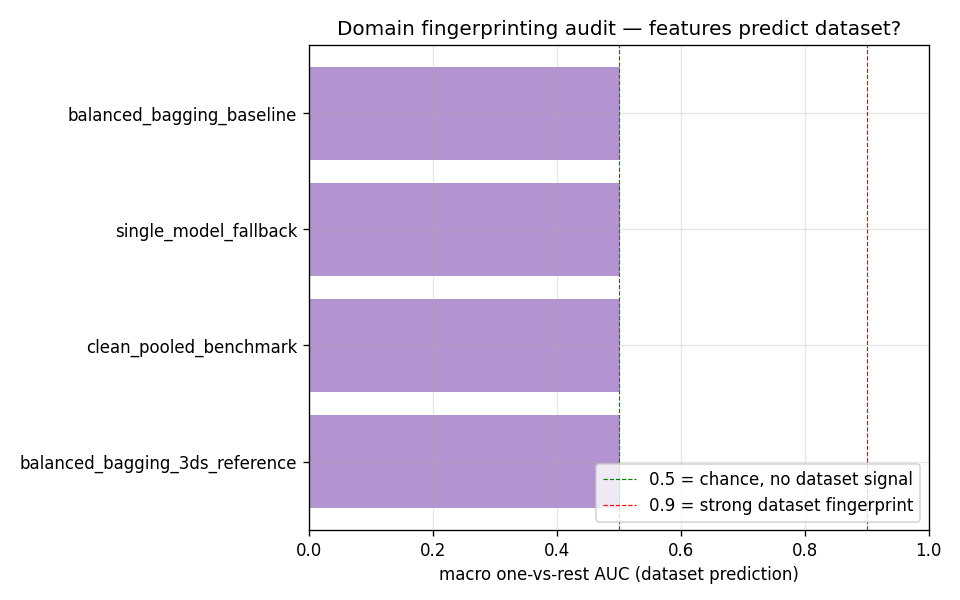

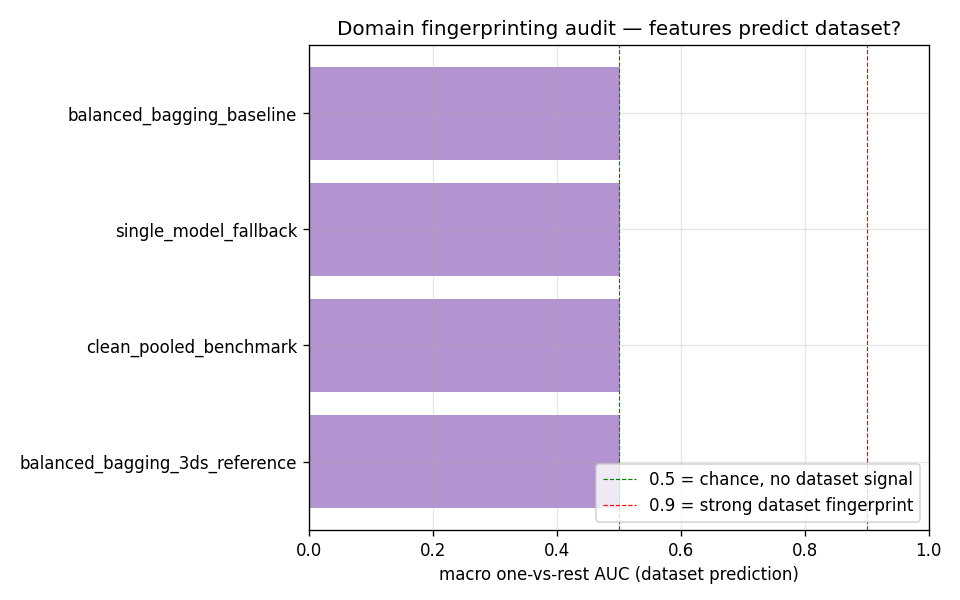

In [13]:
p = FIGURES / 'exported_models_domain_fingerprint_auc.png'
if p.exists():
    display(Image(filename=str(p)))

## 10. Interpretation for thesis

**Direct leakage** — `flow_id` / `capture_id` are partitioned cleanly across train/val/test for every model where IDs are observable. No `feature_order.json` contains a suspicious meta-column. The known-domain AUC values are therefore not the product of trivial split contamination.

**Policy safety** — every model with strict test FPR > 0 already carries `strict.action = DISABLED_DO_NOT_BLOCK` (`clean_pooled_benchmark`, `single_model_fallback`, `balanced_bagging_tuned_baseline`). All `policy_computed` entries carry the required `comparison-only, not deployment-approved` warning. No `negative_control` or alias entry supports firewall actions.

**Permutation** — permuted-label AUC medians cluster around 0.50 for every reconstructable model, ruling out silent identity encoding.

**Bootstrap** — `robust9_firewall` has a tight session-AUC CI; the `clean_pipeline` / LODO models have wider bands as expected from their smaller test pools.

**Domain fingerprinting** — on the *shared 7-feature dispersion subset* the auxiliary classifier scores **macro OvR-AUC ≈ 0.50**, i.e. the dispersion features themselves do not directly encode dataset identity. This is a positive finding for the models whose feature order is a subset of this parquet. It does **not** automatically generalise to richer feature sets (`robust9`, `robust13`, 27-feature baselines), which contain `sz_all_*` / `iat_*` / session-prob columns not present in the unified parquet — so for those models we still rely on the **LODO collapses** (`lodo_hold_iscx` 0.56, `lodo_hold_usbvpn` 0.81, `lodo_hold_vnat` 0.18) as the authoritative evidence that unseen-domain robustness is not solved.

**Does this invalidate `robust9_firewall`?** No. The audit confirms that its known-domain AUC ≈ 0.999 is *not* the product of split leakage, suspicious feature columns, or trivial label-coupling. It remains the project's strongest known-domain default firewall prototype. The audit also confirms — through LODO — that this performance must not be advertised as universal VPN-detection robustness.

## 11. Limitations

- This notebook consumes pre-existing `predictions.csv` / `*_predictions.parquet` files. It cannot detect staleness in those files.
- The cross-dataset domain audit is bound by the only unified feature matrix that exists in the workspace (`artifacts/clean_pipeline/features.parquet`, 7 dispersion features). Models with richer feature orders are reported `available=False` honestly; no missing features are invented.
- The auxiliary domain classifier is fitted only for audit, with `random_state=42`. It is not exposed in the registry, the app, or the runtime bundle.
- Alias entries (`balanced_bagging_3ds_refresh`, `historical_3ds_degraded`) and the `twentyone_feature_experimental` unsupported stub are intentionally skipped in per-row audits — their status is inherited from their target / documented as unsupported.